# MLP trined to predict data from the MNIST dataset

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from mlp import MLP, Layer
from activations import Relu, SoftMax, LeakyRelu
from losses import CrossEntropyLoss
from utils import OneHotEncoder

In [2]:
mnist = fetch_openml('mnist_784', version=1)
X = mnist.data.to_numpy() / 255.0
Y = mnist.target.astype(int).to_numpy()

encoder = OneHotEncoder()

Y = encoder.encode(Y, num_classes=10)

X_train, X_test = X[:60000], X[60000:]
y_train, y_test = Y[:60000], Y[60000:]

In [ ]:
mlp = MLP()
mlp.add_layer(Layer(784, 128, Relu()))
mlp.add_layer(Layer(128, 64, Relu()))
mlp.add_layer(Layer(64, 10, SoftMax()))

loss_fn = CrossEntropyLoss()
learning_rate = 0.5

In [32]:
epochs = 10
losses = []
for epoch in range(epochs):
    epoch_loss = 0
    for x, y_true in zip(X_train, y_train):
        y_pred = mlp.forward(x)
        epoch_loss += loss_fn.forward(y_pred, y_true)
        delta = loss_fn.backward(y_pred, y_true)
        mlp.backward(delta)
        mlp.update(learning_rate)
    
    losses.append(epoch_loss / len(X_train))
    print(f"Epoch {epoch+1}/{epochs}  Loss: {losses[-1]}")


/home/karl/Documents/dev/own_neural_network/src/mlp.py:13: RuntimeWarning: overflow encountered in dot
  self.pre_activation = np.dot(self.weights, x) + self.biases
/home/karl/Documents/dev/own_neural_network/src/activations.py:29: RuntimeWarning: invalid value encountered in subtract
  exp = np.exp(x - np.max(x))


Epoch 1/10  Loss: nan


KeyboardInterrupt: 

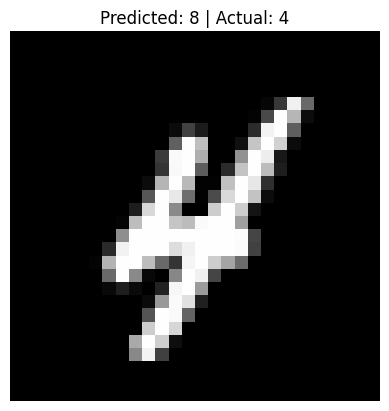

Predicted: 8 | Actual: 4


In [28]:
index = np.random.randint(0, len(X_test))
x = X_test[index]
y_true = y_test[index]

y_pred = mlp.forward(x)
predicted = np.argmax(y_pred)
actual = np.argmax(y_true)

image = x.reshape(28, 28)
plt.imshow(image, cmap='gray')
plt.title(f"Predicted: {predicted} | Actual: {actual}")
plt.axis('off')
plt.show()
print(f"Predicted: {predicted} | Actual: {actual}")